In [1]:
import math
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
class Neuron:
    def __init__(self, n_inputs, activation='sigmoid'):
        self.n_inputs   = n_inputs
        self.weights    = [0.0] * n_inputs
        self.bias       = 0.0
        self.z          = 0.0
        self.output     = 0.0
        self.activation = activation   # 'sigmoid' or 'linear'

    @staticmethod
    def sigmoid(z):
        if z >= 0:
            return 1.0 / (1.0 + math.exp(-z))
        e = math.exp(z)
        return e / (1.0 + e)

    def forward(self, inputs):
        self.z = sum(self.weights[j] * inputs[j]
                     for j in range(self.n_inputs)) + self.bias
        if self.activation == 'sigmoid':
            self.output = self.sigmoid(self.z)
        else:                              # linear
            self.output = self.z
        return self.output

    def __repr__(self):
        w_str = ', '.join(f'{w:+.4f}' for w in self.weights)
        return f'Neuron(bias={self.bias:+.4f}, weights=[{w_str}])'

In [3]:
class Layer:
    def __init__(self, n_neurons, n_inputs, activation='sigmoid'):
        self.n_neurons  = n_neurons
        self.n_inputs   = n_inputs
        self.activation = activation
        self.neurons    = [Neuron(n_inputs, activation)
                           for _ in range(n_neurons)]

    def forward(self, inputs):
        return [n.forward(inputs) for n in self.neurons]

    def __repr__(self):
        return (f'Layer({self.n_neurons} neurons, '
                f'{self.n_inputs} inputs, act={self.activation})')

In [4]:
class NeuralNetwork:
    def __init__(self):
        self.layers      = []
        self.layer_sizes = []

    # ─── Factory ───
    @classmethod
    def build(cls, sizes, output_activation='sigmoid'):
        """Build a network from a list of layer sizes."""
        nn = cls()
        nn.layer_sizes = list(sizes)
        for l in range(1, len(sizes)):
            act = output_activation if l == len(sizes) - 1 else 'sigmoid'
            nn.layers.append(Layer(sizes[l], sizes[l - 1], activation=act))
        return nn

    # ─── Initialisation ───
    def init_random(self, seed=None):
        if seed is not None:
            random.seed(seed)
        for layer in self.layers:
            for neuron in layer.neurons:
                scale          = math.sqrt(2.0 / neuron.n_inputs)  # He init
                neuron.bias    = 0.0
                neuron.weights = [random.gauss(0, scale)
                                  for _ in neuron.weights]

    # ─── Inference ───
    def feedforward(self, inputs):
        current = list(inputs)
        for layer in self.layers:
            current = layer.forward(current)
        return current

    # ─── Training: backpropagation + gradient descent ───
    def train(self, X, Y, lr=0.1, epochs=1000, mode='bce',
              verbose=True, verbose_every=500):
        """
        mode='bce'  -> BCE loss + sigmoid output (classification)
        mode='mse'  -> MSE loss + linear  output (regression)
        """
        loss_history = []
        N   = len(X)
        eps = 1e-15

        for epoch in range(epochs):
            # Gradient accumulators: grad_W[l][k][j], grad_b[l][k]
            grad_W = [[[0.0] * len(n.weights) for n in layer.neurons]
                      for layer in self.layers]
            grad_b = [[0.0] * layer.n_neurons for layer in self.layers]
            total_loss = 0.0

            for i in range(N):
                x_i = list(X[i])
                y_i = Y[i]

                # ── Forward pass ──
                activations = [x_i]
                for layer in self.layers:
                    activations.append(layer.forward(activations[-1]))
                y_hat = activations[-1][0]

                # ── Loss ──
                if mode == 'bce':
                    yc = max(eps, min(1 - eps, y_hat))
                    total_loss += -(y_i * math.log(yc)
                                    + (1 - y_i) * math.log(1 - yc))
                else:                              # mse
                    total_loss += 0.5 * (y_hat - y_i) ** 2

                # ── Backward pass ──
                L      = len(self.layers) - 1
                deltas = [None] * len(self.layers)

                # Output-layer delta
                out_act = self.layers[L].activation
                if mode == 'bce' and out_act == 'sigmoid':
                    # dBCE/dz = yhat - y  (sigmoid derivative cancels)
                    deltas[L] = [y_hat - y_i]
                elif mode == 'mse' and out_act == 'linear':
                    # dMSE/dz = yhat - y  (linear: dy/dz = 1)
                    deltas[L] = [y_hat - y_i]
                else:
                    # MSE + sigmoid: dMSE/dz = (yhat-y)*yhat*(1-yhat)
                    deltas[L] = [(y_hat - y_i) * y_hat * (1 - y_hat)]

                # Hidden-layer deltas (right to left)
                for l in range(L - 1, -1, -1):
                    next_layer = self.layers[l + 1]
                    deltas[l]  = []
                    for k in range(self.layers[l].n_neurons):
                        a_k = activations[l + 1][k]
                        # Chain rule: sum over next-layer neurons
                        err = sum(next_layer.neurons[j].weights[k]
                                  * deltas[l + 1][j]
                                  for j in range(next_layer.n_neurons))
                        # Sigmoid derivative: a*(1-a)
                        deltas[l].append(err * a_k * (1 - a_k))

                # Accumulate gradients
                for l, layer in enumerate(self.layers):
                    for k, neuron in enumerate(layer.neurons):
                        for j in range(len(neuron.weights)):
                            grad_W[l][k][j] += activations[l][j] * deltas[l][k]
                        grad_b[l][k] += deltas[l][k]

            # ── Weight update (stochastic gradient descent) ──
            for l, layer in enumerate(self.layers):
                for k, neuron in enumerate(layer.neurons):
                    for j in range(len(neuron.weights)):
                        neuron.weights[j] -= lr * grad_W[l][k][j] / N
                    neuron.bias -= lr * grad_b[l][k] / N

            avg_loss = total_loss / N
            loss_history.append(avg_loss)

            if verbose and (epoch + 1) % verbose_every == 0:
                print(f'  Epoch {epoch+1:5d}/{epochs}  loss={avg_loss:.6f}')

        return loss_history

    def summary(self):
        arch = ' -> '.join(str(s) for s in self.layer_sizes)
        print(f'NeuralNetwork [{arch}]')
        for l, layer in enumerate(self.layers):
            print(f'  Layer {l+1}: {layer}')
            for n, neuron in enumerate(layer.neurons):
                print(f'    Neuron {n+1}: {neuron}')

In [5]:
# ══════════════════════════════════════════════════════════
#  EXPERIMENT 1 – XOR dataset (classification, BCE loss)
# ══════════════════════════════════════════════════════════
X_xor = [[0, 0], [0, 1], [1, 0], [1, 1]]
Y_xor = [0, 1, 1, 0]

print('XOR dataset:')
print(f'{"x1":>4} {"x2":>4}  {"y":>4}')
for (x1, x2), y in zip(X_xor, Y_xor):
    print(f'{x1:>4} {x2:>4}  {y:>4}')

XOR dataset:
  x1   x2     y
   0    0     0
   0    1     1
   1    0     1
   1    1     0


In [6]:
LRS_XOR = [0.1, 0.5, 1.0, 2.0]
EPOCHS  = 5000
SEED    = 42

xor_losses = {}
xor_models  = {}

for lr in LRS_XOR:
    print(f'\n--- Training XOR  lr={lr} ---')
    nn = NeuralNetwork.build([2, 4, 1], output_activation='sigmoid')
    nn.init_random(seed=SEED)
    losses = nn.train(X_xor, Y_xor, lr=lr, epochs=EPOCHS,
                      mode='bce', verbose=True, verbose_every=1000)
    xor_losses[lr] = losses
    xor_models[lr] = nn
    correct = sum(1 for xi, yi in zip(X_xor, Y_xor)
                  if (1 if nn.feedforward(xi)[0] >= 0.5 else 0) == yi)
    print(f'  => Final BCE loss={losses[-1]:.6f}  Accuracy={correct}/4={100*correct//4}%')


--- Training XOR  lr=0.1 ---
  Epoch  1000/5000  loss=0.692843
  Epoch  2000/5000  loss=0.688654
  Epoch  3000/5000  loss=0.625272
  Epoch  4000/5000  loss=0.486835


  Epoch  5000/5000  loss=0.277813
  => Final BCE loss=0.277813  Accuracy=4/4=100%

--- Training XOR  lr=0.5 ---


  Epoch  1000/5000  loss=0.282138
  Epoch  2000/5000  loss=0.019194
  Epoch  3000/5000  loss=0.008451
  Epoch  4000/5000  loss=0.005296


  Epoch  5000/5000  loss=0.003826
  => Final BCE loss=0.003826  Accuracy=4/4=100%

--- Training XOR  lr=1.0 ---
  Epoch  1000/5000  loss=0.019253


  Epoch  2000/5000  loss=0.005294
  Epoch  3000/5000  loss=0.002981
  Epoch  4000/5000  loss=0.002059


  Epoch  5000/5000  loss=0.001568
  => Final BCE loss=0.001568  Accuracy=4/4=100%

--- Training XOR  lr=2.0 ---
  Epoch  1000/5000  loss=0.005285


  Epoch  2000/5000  loss=0.002053
  Epoch  3000/5000  loss=0.001260
  Epoch  4000/5000  loss=0.000906


  Epoch  5000/5000  loss=0.000706
  => Final BCE loss=0.000706  Accuracy=4/4=100%


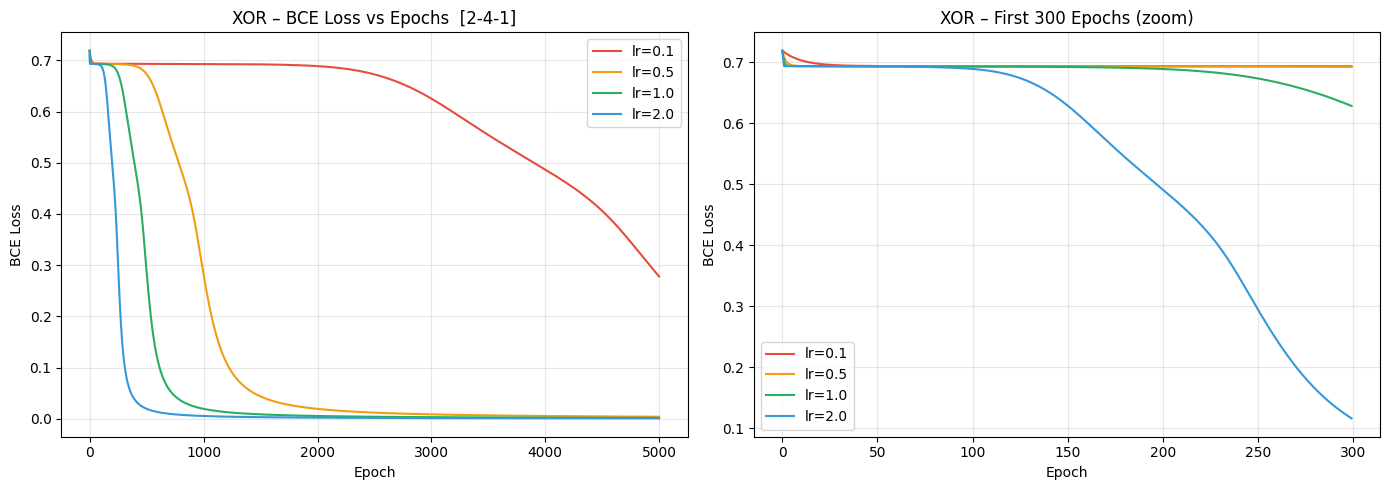

Saved: backprop_xor_loss.png


In [7]:
colors4 = ['#E74C3C', '#F39C12', '#27AE60', '#3498DB']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for (lr, losses), color in zip(xor_losses.items(), colors4):
    ax.plot(losses, label=f'lr={lr}', color=color, linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('XOR – BCE Loss vs Epochs  [2-4-1]')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for (lr, losses), color in zip(xor_losses.items(), colors4):
    ax2.plot(losses[:300], label=f'lr={lr}', color=color, linewidth=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('BCE Loss')
ax2.set_title('XOR – First 300 Epochs (zoom)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('backprop_xor_loss.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: backprop_xor_loss.png')

In [8]:
best_lr_xor  = min(xor_losses, key=lambda lr: xor_losses[lr][-1])
nn_xor_best  = xor_models[best_lr_xor]

print(f'Best lr={best_lr_xor}  final_loss={xor_losses[best_lr_xor][-1]:.6f}')
print()
print(f'{"x1":>3} {"x2":>3}  {"Expected":>9}  {"Output":>8}  {"Pred":>5}  {"OK?":>4}')
print('-' * 44)

xor_outputs, xor_flags = [], []
for (x1, x2), yi in zip(X_xor, Y_xor):
    yhat = nn_xor_best.feedforward([x1, x2])[0]
    pred = 1 if yhat >= 0.5 else 0
    ok   = (pred == yi)
    xor_outputs.append(yhat)
    xor_flags.append(ok)
    print(f'{x1:>3} {x2:>3}  {yi:>9}  {yhat:>8.4f}  {pred:>5}  {"OK" if ok else "FAIL":>4}')

acc_xor = sum(xor_flags) / len(xor_flags) * 100
print(f'\nAccuracy: {sum(xor_flags)}/4 = {acc_xor:.0f}%')

Best lr=2.0  final_loss=0.000706

 x1  x2   Expected    Output   Pred   OK?
--------------------------------------------
  0   0          0    0.0008      0    OK
  0   1          1    0.9993      1    OK
  1   0          1    0.9993      1    OK
  1   1          0    0.0006      0    OK

Accuracy: 4/4 = 100%


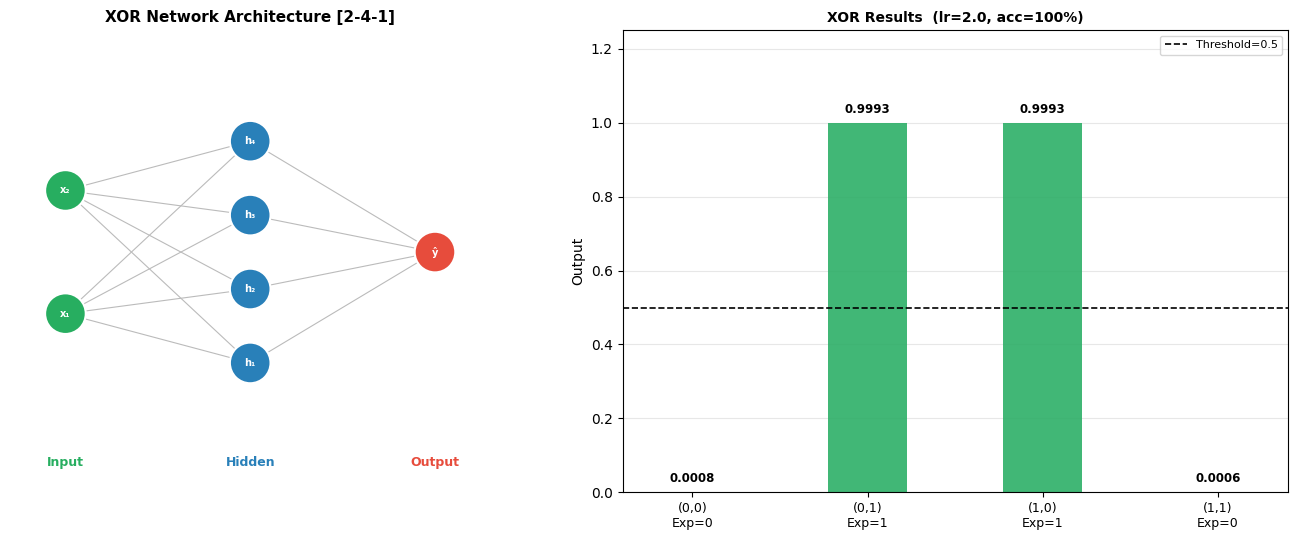

Saved: backprop_xor_results.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: network architecture diagram
ax = axes[0]
layer_sizes = [2, 4, 1]
n_layers    = len(layer_sizes)
positions   = []
for l, size in enumerate(layer_sizes):
    x   = l / (n_layers - 1)
    col = [(x, (n + 1) / (size + 1)) for n in range(size)]
    positions.append(col)

for l in range(1, n_layers):
    for (x0, y0) in positions[l - 1]:
        for (x1, y1) in positions[l]:
            ax.plot([x0, x1], [y0, y1], color='#BBBBBB', linewidth=0.8, zorder=1)

lc = ['#27AE60', '#2980B9', '#E74C3C']
ln = [['x₁', 'x₂'], ['h₁', 'h₂', 'h₃', 'h₄'], ['ŷ']]
nr = 0.055
for l, (col, color) in enumerate(zip(positions, lc)):
    for n, (x, y) in enumerate(col):
        c = plt.Circle((x, y), nr, color=color, zorder=2, ec='white', lw=1.5)
        ax.add_patch(c)
        ax.text(x, y, ln[l][n], ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=3)
ax.text(0.0,  -0.08, 'Input',  ha='center', fontsize=9, fontweight='bold', color=lc[0])
ax.text(0.5,  -0.08, 'Hidden', ha='center', fontsize=9, fontweight='bold', color=lc[1])
ax.text(1.0,  -0.08, 'Output', ha='center', fontsize=9, fontweight='bold', color=lc[2])
ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.15, 1.10)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('XOR Network Architecture [2-4-1]', fontsize=11, fontweight='bold')

# Right: bar chart of outputs
ax2    = axes[1]
x_pos  = list(range(4))
x_lbls = ['(0,0)\nExp=0', '(0,1)\nExp=1', '(1,0)\nExp=1', '(1,1)\nExp=0']
clrs   = ['#27AE60' if f else '#E74C3C' for f in xor_flags]
bars   = ax2.bar(x_pos, xor_outputs, color=clrs, alpha=0.85, width=0.45, zorder=2)
ax2.bar(x_pos, Y_xor, color='#3498DB', alpha=0.20, width=0.45, zorder=1)
ax2.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold=0.5')
for b, v in zip(bars, xor_outputs):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.4f}',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax2.set_xticks(x_pos); ax2.set_xticklabels(x_lbls, fontsize=9)
ax2.set_ylabel('Output'); ax2.set_ylim(0, 1.25)
ax2.set_title(f'XOR Results  (lr={best_lr_xor}, acc={acc_xor:.0f}%)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('backprop_xor_results.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: backprop_xor_results.png')

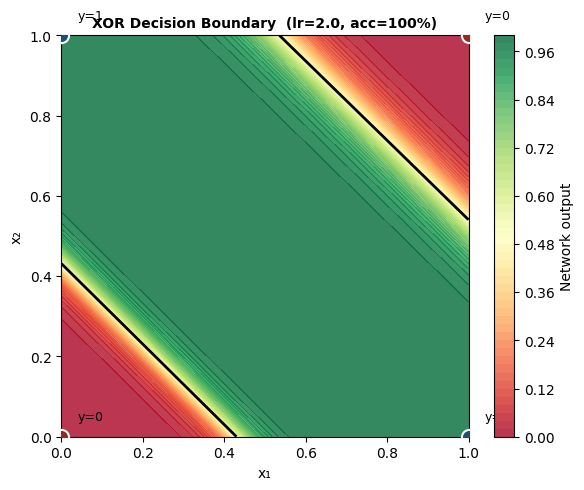

Saved: backprop_xor_decision.png


In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
res = 200
xs  = [i / res for i in range(res + 1)]
ys  = [j / res for j in range(res + 1)]
Z   = [[nn_xor_best.feedforward([x, y])[0] for x in xs] for y in ys]

cf = ax.contourf(xs, ys, Z, levels=50, cmap='RdYlGn', alpha=0.8)
plt.colorbar(cf, ax=ax, label='Network output')
ax.contour(xs, ys, Z, levels=[0.5], colors='black', linewidths=2)

for (x1, x2), yi in zip(X_xor, Y_xor):
    c = '#1A5276' if yi == 1 else '#922B21'
    ax.scatter(x1, x2, c=c, s=120, zorder=5, edgecolors='white', linewidths=1.5)
    ax.text(x1 + 0.04, x2 + 0.04, f'y={yi}', fontsize=9)

ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title(f'XOR Decision Boundary  (lr={best_lr_xor}, acc={acc_xor:.0f}%)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('backprop_xor_decision.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: backprop_xor_decision.png')

In [11]:
# ══════════════════════════════════════════════════════════
#  EXPERIMENT 2 – House Price dataset (regression, MSE loss)
# ══════════════════════════════════════════════════════════
with open('house_price.csv', 'r') as f:
    lines = f.readlines()

X_raw, Y_raw = [], []
for line in lines[1:]:           # skip header
    parts = line.strip().split(',')
    X_raw.append(float(parts[0]))
    Y_raw.append(float(parts[1]))

print(f'Loaded {len(X_raw)} samples')
print(f'Sizes:  {X_raw}')
print(f'Prices: {Y_raw}')

# Normalise to [0, 1]
x_min, x_max = min(X_raw), max(X_raw)
y_min, y_max = min(Y_raw), max(Y_raw)

def normalise(val, vmin, vmax):
    return (val - vmin) / (vmax - vmin)

def denormalise(val, vmin, vmax):
    return val * (vmax - vmin) + vmin

X_house = [[normalise(x, x_min, x_max)] for x in X_raw]
Y_house = [normalise(y, y_min, y_max)   for y in Y_raw]

print(f'\nNorm. X: {[f"{x[0]:.4f}" for x in X_house]}')
print(f'Norm. Y: {[f"{y:.4f}" for y in Y_house]}')

Loaded 5 samples
Sizes:  [10.0, 20.0, 40.0, 60.0, 80.0]
Prices: [55.0, 80.0, 100.0, 120.0, 150.0]

Norm. X: ['0.0000', '0.1429', '0.4286', '0.7143', '1.0000']
Norm. Y: ['0.0000', '0.2632', '0.4737', '0.6842', '1.0000']


In [12]:
LRS_HOUSE = [0.01, 0.05, 0.1, 0.5]
EPOCHS_H  = 3000
SEED_H    = 0

house_losses = {}
house_models  = {}

for lr in LRS_HOUSE:
    print(f'\n--- Training House Price  lr={lr} ---')
    nn = NeuralNetwork.build([1, 4, 1], output_activation='linear')
    nn.init_random(seed=SEED_H)
    losses = nn.train(X_house, Y_house, lr=lr, epochs=EPOCHS_H,
                      mode='mse', verbose=True, verbose_every=600)
    house_losses[lr] = losses
    house_models[lr] = nn
    print(f'  => Final MSE (normalised) = {losses[-1]:.6f}')

best_lr_house = min(house_losses, key=lambda lr: house_losses[lr][-1])
nn_house_best = house_models[best_lr_house]
print(f'\nBest lr={best_lr_house}  final_MSE={house_losses[best_lr_house][-1]:.6f}')


--- Training House Price  lr=0.01 ---
  Epoch   600/3000  loss=0.060134
  Epoch  1200/3000  loss=0.037995
  Epoch  1800/3000  loss=0.023688
  Epoch  2400/3000  loss=0.014495
  Epoch  3000/3000  loss=0.008800
  => Final MSE (normalised) = 0.008800

--- Training House Price  lr=0.05 ---
  Epoch   600/3000  loss=0.008816


  Epoch  1200/3000  loss=0.001667
  Epoch  1800/3000  loss=0.001385
  Epoch  2400/3000  loss=0.001368


  Epoch  3000/3000  loss=0.001359
  => Final MSE (normalised) = 0.001359

--- Training House Price  lr=0.1 ---
  Epoch   600/3000  loss=0.001667
  Epoch  1200/3000  loss=0.001368
  Epoch  1800/3000  loss=0.001351
  Epoch  2400/3000  loss=0.001335


  Epoch  3000/3000  loss=0.001321
  => Final MSE (normalised) = 0.001321

--- Training House Price  lr=0.5 ---
  Epoch   600/3000  loss=0.001320
  Epoch  1200/3000  loss=0.001268


  Epoch  1800/3000  loss=0.001234
  Epoch  2400/3000  loss=0.001211
  Epoch  3000/3000  loss=0.001195
  => Final MSE (normalised) = 0.001195

Best lr=0.5  final_MSE=0.001195


In [13]:
print(f'{"Size":>6}  {"Price (true)":>13}  {"Price (pred)":>13}  {"Error":>8}')
print('-' * 46)
for xi, yi_true in zip(X_raw, Y_raw):
    xn    = normalise(xi, x_min, x_max)
    yn    = nn_house_best.feedforward([xn])[0]
    ypred = denormalise(yn, y_min, y_max)
    err   = abs(ypred - yi_true)
    print(f'{xi:>6.0f}  {yi_true:>13.1f}  {ypred:>13.4f}  {err:>8.4f}')

  Size   Price (true)   Price (pred)     Error
----------------------------------------------
    10           55.0        59.5954    4.5954
    20           80.0        73.0177    6.9823
    40          100.0       100.0867    0.0867
    60          120.0       125.3492    5.3492
    80          150.0       146.9466    3.0534


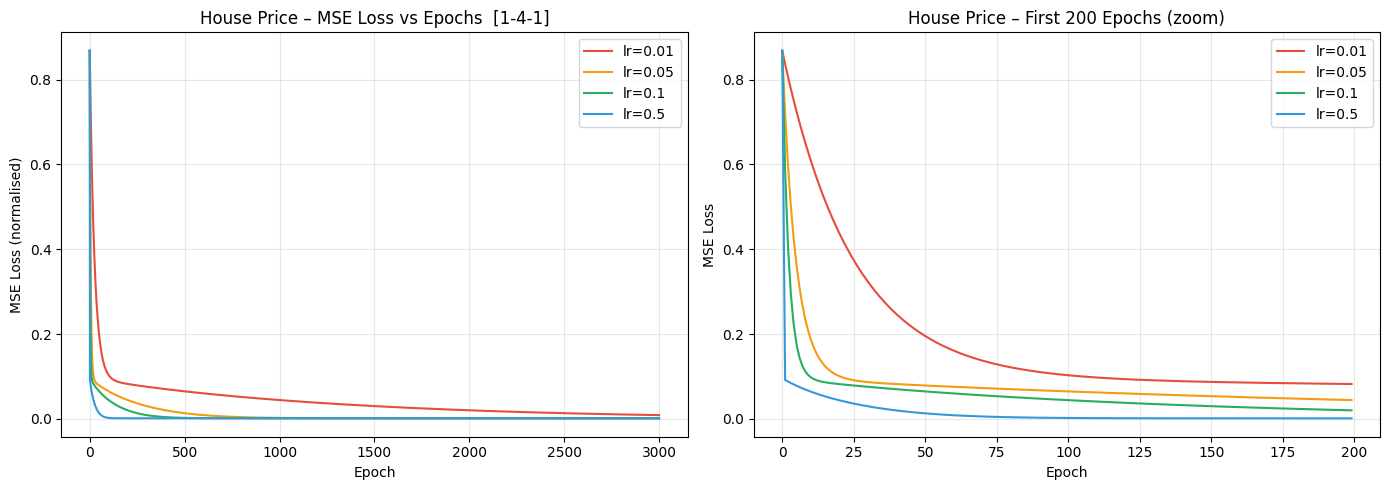

Saved: backprop_house_loss.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for (lr, losses), color in zip(house_losses.items(), colors4):
    ax.plot(losses, label=f'lr={lr}', color=color, linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (normalised)')
ax.set_title('House Price – MSE Loss vs Epochs  [1-4-1]')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for (lr, losses), color in zip(house_losses.items(), colors4):
    ax2.plot(losses[:200], label=f'lr={lr}', color=color, linewidth=1.5)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss')
ax2.set_title('House Price – First 200 Epochs (zoom)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('backprop_house_loss.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: backprop_house_loss.png')

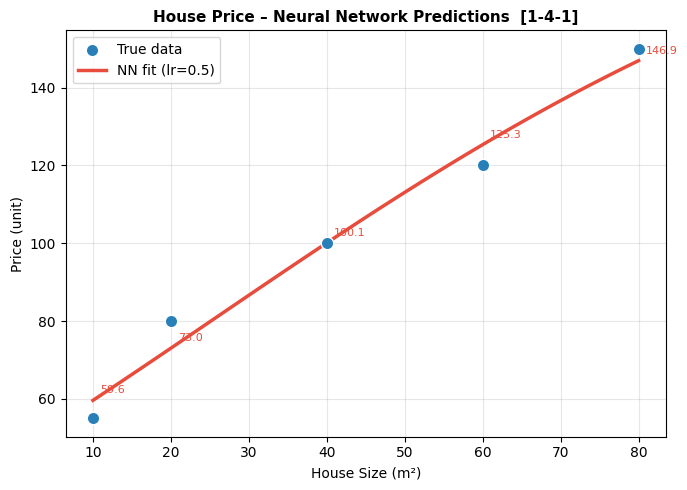

Saved: backprop_house_predictions.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(X_raw, Y_raw, color='#2980B9', s=80, zorder=5,
           label='True data', edgecolors='white', linewidths=1)

x_line = [x_min + (x_max - x_min) * t / 100 for t in range(101)]
y_line = []
for x in x_line:
    xn = normalise(x, x_min, x_max)
    yn = nn_house_best.feedforward([xn])[0]
    y_line.append(denormalise(yn, y_min, y_max))

ax.plot(x_line, y_line, color='#E74C3C', linewidth=2.5,
        label=f'NN fit (lr={best_lr_house})')

for xi, yi_true in zip(X_raw, Y_raw):
    xn    = normalise(xi, x_min, x_max)
    yn    = nn_house_best.feedforward([xn])[0]
    ypred = denormalise(yn, y_min, y_max)
    ax.annotate(f'{ypred:.1f}', (xi, ypred),
                textcoords='offset points', xytext=(5, 5),
                fontsize=8, color='#E74C3C')

ax.set_xlabel('House Size (m²)'); ax.set_ylabel('Price (unit)')
ax.set_title('House Price – Neural Network Predictions  [1-4-1]',
             fontsize=11, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('backprop_house_predictions.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: backprop_house_predictions.png')